In [ ]:
# Random Forest Classifier

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_iris, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

In [26]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ensembles"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Random Forest Classifier

In [9]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [10]:
rnd_clf = RandomForestClassifier(n_estimators = 500, max_leaf_nodes=16, 
                                n_jobs = -1, random_state = 42 )
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

In [14]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(max_features = "sqrt", max_leaf_nodes= 16),
                           n_estimators= 500, n_jobs = -1, random_state = 42)

In [17]:
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
np.all(y_pred_bag == y_pred_rf)

True

## Feature Importance

In [19]:
iris = load_iris(as_frame= True)
rnd_clf = RandomForestClassifier(n_estimators= 500, random_state = 42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


In [28]:
X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y = True, as_frame = False, parser = 'auto')

rnd_clf = RandomForestClassifier(n_estimators= 100, random_state= 42)
rnd_clf.fit(X_mnist, y_mnist)

RandomForestClassifier(random_state=42)

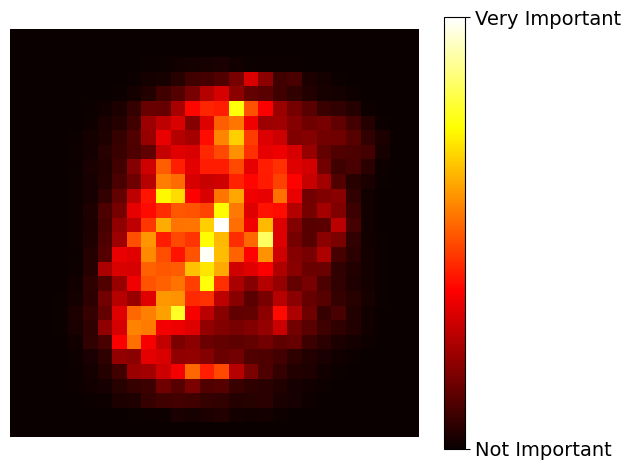

In [29]:
heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap= 'hot')
cbar = plt.colorbar(ticks = [rnd_clf.feature_importances_.min(),
                            rnd_clf.feature_importances_.max()])

cbar.ax.set_yticklabels(["Not Important", "Very Important"], fontsize = 14)
plt.axis("off")
save_fig("mnist_feature_importance_plot")